In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import pdfplumber
from urllib.request import urlretrieve
from IPython.display import display, Markdown, HTML, Image

In [3]:
import os
print(os.getcwd())

/Commjhub/jupyterhub/home/sphiawang/comm3180_S26/comm3180_G3_Data_Project/data_analysis/Business Schools


## Gies and Wharton Industry Placements: School Culture and Career Pipelines

As part of my qualitative analysis on both business schools, I looked into what specific industries each college enters and what that might reveal about the student body. This data was found from each school's career outcomes 2025 report. I used Claude to extract this data into a csv file and display it in a pie chart.

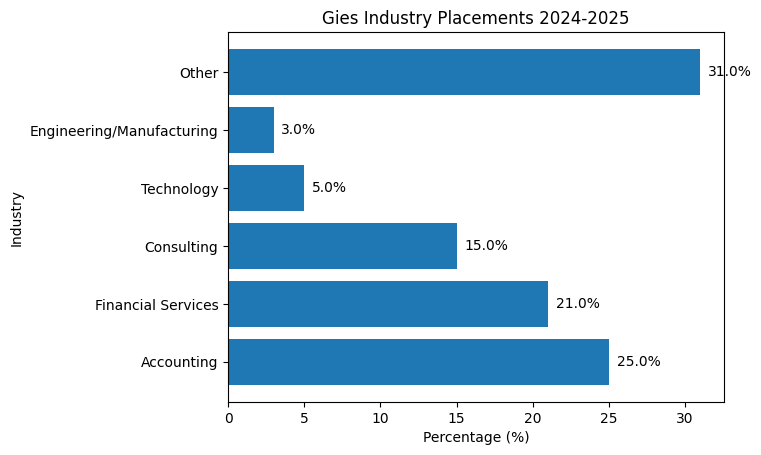

In [7]:
df = pd.read_csv('../../data/raw/Business_Schools/IndustryPlacements.csv')

gies = df[df['Gies_Pct'] > 0]
wharton = df[df['Wharton_Pct'] > 0]

plt.figure()
plt.barh(gies['Industry'], gies['Gies_Pct'])

plt.xlabel('Percentage (%)')
plt.ylabel('Industry')
plt.title('Gies Industry Placements 2024-2025')

for i, v in enumerate(gies['Gies_Pct']):
    plt.text(v + 0.5, i, f'{v:.1f}%', va='center')

plt.show()

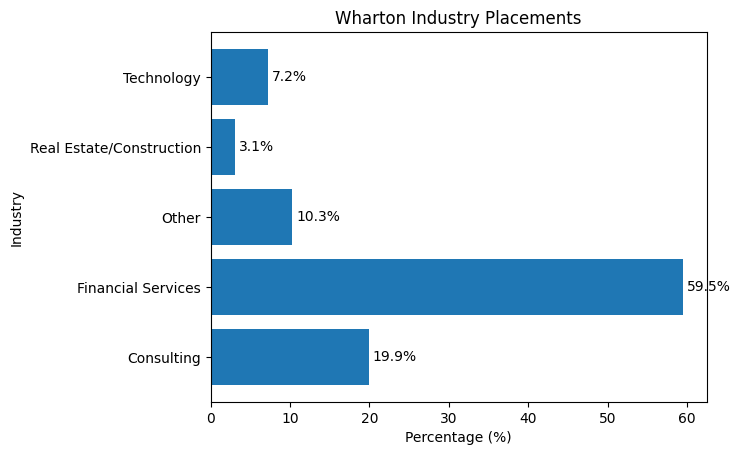

In [6]:
plt.figure()

wharton = df[df['Wharton_Pct'] > 0].copy()
wharton.loc[wharton['Wharton_Pct'] < 3, 'Industry'] = 'Other'
wharton = wharton.groupby('Industry')['Wharton_Pct'].sum().reset_index()

plt.barh(wharton['Industry'], wharton['Wharton_Pct'])

plt.xlabel('Percentage (%)')
plt.ylabel('Industry')
plt.title('Wharton Industry Placements')

for i, v in enumerate(wharton['Wharton_Pct']):
    plt.text(v + 0.5, i, f'{v:.1f}%', va='center')

plt.show()

Clearly, Gies has a more diverse career outcome with industries in accounting, consulting, finance, technology, and other. Wharton is heavily concentrated in finance and consulting, with little to no room for other industries. I actually had to aggregate all the other Wharton industries into other or technology because of how little the student body enters them. For Gies, I didn't have to.

These numbers actually reflect online sentiments about each school. Wharton is notorious for its cut-throat environment which inadvertently influences many Wharton (and non-Wharton) students to pursue coveted industries like IB. Along with previous years doing the same (stronger alumni base in that industry), many Wharton graduates enter either finance or consulting-- it is quite rare to find a Wharton grad who is not in either field post-grad. Penn is known for being a stressful environment with many students citing the pre-professional culture as the main culprit. I think this pie chart subtly demonstrates this culture on campus. Gies, on the otherhand, demonstrates both the strength in the accounting program and the flexible career options students pursue post-grad. 